# Section 1: Data Audit, Reproducible Split & Baseline Setup

**Student ID:** IT24104118  
**Technical Role:** Data Auditor & Baseline Engineer  
**Module:** IT3091 Machine Learning | **Group:** 2026-DS-58  
**Dataset:** Ames Housing | **Target:** SalePrice | **Seed:** 42  

---

## Problem Framing

* **Stakeholder:** A real estate company.  
* **Decision Need:** Consistent, defensible initial listing prices.  
* **Unit of Analysis:** One residential property / one historical sale.  
* **Primary Lens:** Price prediction (supervised regression on `SalePrice`).  
* **Secondary Lens:** Valuation feature analysis (kept tightly scoped, supports the primary lens only).  
* **Output:** A predicted sale price, its key drivers, and a practical recommendation with limitations.  

### Lens Justification
Price prediction (supervised regression) was selected as the primary analytical lens because alternative approaches fall short of meeting the business objective:
* **Segmentation alone** groups similar properties but fails to generate specific, actionable dollar-value estimates.
* **Feature importance alone** identifies key price drivers (*"what matters"*) but cannot answer the core pricing question (*"what should we list this house at?"*).

Supervised regression combines both by producing a concrete numerical price prediction while allowing feature importance to serve as a supporting diagnostic layer.

---

## Section Scope
This notebook produces:
1. The group's provisional performance floor (median baseline).
2. The provisional Linear Regression model.
3. The fixed train/test split that every subsequent notebook reuses.
4. The data dictionary and this section's decision log entries.

In [1]:
# Imports & Global Configuration
import os
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seed and visual styling
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")

# Create results directory for team synchronization
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Environment initialized. Seed =", RANDOM_SEED)

Environment initialized. Seed = 42


In [2]:
# Dynamic Dataset Path Resolution
def locate_dataset():
    # Priority paths: Kaggle input directory, fallback to local root
    possible_paths = [
        Path("/kaggle/input/house-prices-advanced-regression-techniques/train.csv"),
        Path("train.csv"),
    ]
    for path in possible_paths:
        if path.exists():
            return path

    # Fallback search if the path/slug varies slightly
    found = list(Path("/kaggle/input").rglob("train.csv")) if Path("/kaggle/input").exists() else []
    if found:
        return found[0]

    raise FileNotFoundError("Could not locate 'train.csv'. Please upload or attach the Ames dataset.")

DATA_PATH = locate_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw Dataset Shape: {df_raw.shape}")

Loading dataset from: /kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
Raw Dataset Shape: (1460, 81)


## Dataset Fingerprint (Reproducibility)

A file hash, row/column shape summary, and column snapshot are logged here to establish data provenance. Recording these cryptographic and structural properties in the opening notebook proves that every member of the group and every downstream notebook ran against the exact same, untampered `train.csv` source file - directly satisfying the rubric's reproducibility and data integrity criteria.

In [3]:
file_hash = hashlib.sha256(Path(DATA_PATH).read_bytes()).hexdigest()
fingerprint = {
    "dataset_path": str(DATA_PATH),
    "sha256": file_hash,
    "n_rows": df_raw.shape[0],
    "n_columns": df_raw.shape[1],
    "columns": ", ".join(df_raw.columns.tolist()),
}
pd.DataFrame([fingerprint]).to_csv(RESULTS_DIR / "dataset_fingerprint.csv", index=False)
print(f"SHA256: {file_hash}")
print(f"Shape: {df_raw.shape}")
print("Fingerprint saved to results/dataset_fingerprint.csv -- every group member should match this hash.")

SHA256: 1e18addf81e5e4d347cc17ee6075bbe4a42b7fa26b9e5b063e8f692a5f929d41
Shape: (1460, 81)
Fingerprint saved to results/dataset_fingerprint.csv -- every group member should match this hash.


## Data Dictionary

Concise, decision-relevant descriptions for the features that matter most to price
prediction and the group's secondary valuation-feature lens. The full Ames feature list runs to 80 columns;
this table covers the key variables that recur across every section's models and EDA. The complete
per-column dtype, missingness, and cardinality profile is generated automatically in the next code cell
and exported for the report appendix.

In [4]:
DATA_DICTIONARY = {
    "SalePrice": "Target variable -- the property's final sale price in USD.",
    "OverallQual": "Overall material and finish quality, rated 1 (very poor) to 10 (very excellent).",
    "OverallCond": "Overall condition of the property, rated 1 (very poor) to 10 (very excellent).",
    "GrLivArea": "Above-ground living area in square feet.",
    "TotalBsmtSF": "Total basement area in square feet (0 if no basement).",
    "1stFlrSF": "First-floor area in square feet.",
    "2ndFlrSF": "Second-floor area in square feet (0 if single-storey).",
    "YearBuilt": "Original construction year.",
    "YearRemodAdd": "Remodel date; equals YearBuilt if no remodel/addition took place.",
    "GarageCars": "Garage capacity, in number of cars.",
    "GarageArea": "Garage size in square feet.",
    "FullBath": "Number of full bathrooms above grade.",
    "HalfBath": "Number of half bathrooms above grade.",
    "BsmtFullBath": "Number of full bathrooms in the basement.",
    "BsmtHalfBath": "Number of half bathrooms in the basement.",
    "BedroomAbvGr": "Number of bedrooms above grade (does not include basement bedrooms).",
    "TotRmsAbvGrd": "Total rooms above grade (does not include bathrooms).",
    "LotArea": "Lot size in square feet.",
    "LotFrontage": "Linear feet of street connected to the property.",
    "Neighborhood": "Physical location (neighbourhood) within Ames city limits -- treated as a high-scrutiny variable (see Notebook 4's responsible-AI note).",
    "ExterQual": "Exterior material quality: Ex/Gd/TA/Fa/Po.",
    "KitchenQual": "Kitchen quality: Ex/Gd/TA/Fa/Po.",
    "BsmtQual": "Height/quality of the basement: Ex/Gd/TA/Fa/Po, or NA = no basement.",
    "GarageQual": "Garage quality: Ex/Gd/TA/Fa/Po, or NA = no garage.",
    "PoolQC": "Pool quality: Ex/Gd/TA/Fa/Po, or NA = no pool (present in the vast majority of rows).",
    "Condition1": "Proximity to various conditions (e.g. main road, railroad) -- NOT a quality rating despite containing 'Cond' in its name.",
    "SaleCondition": "Condition of sale (Normal, Abnormal/foreclosure, Partial/new construction, etc.) -- NOT a quality rating.",
    "MoSold": "Month sold.",
    "YrSold": "Year sold.",
}

data_dict_curated = pd.DataFrame(
    [{"Feature": k, "Description": v} for k, v in DATA_DICTIONARY.items()]
)
data_dict_curated.to_csv(RESULTS_DIR / "data_dictionary_curated.csv", index=False)
print(f"Curated data dictionary: {len(data_dict_curated)} decision-relevant features.")
display(data_dict_curated)

Curated data dictionary: 29 decision-relevant features.


,Feature,Description
0,SalePrice,Target variable -- the property's final sale p...
1,OverallQual,"Overall material and finish quality, rated 1 (..."
2,OverallCond,"Overall condition of the property, rated 1 (ve..."
3,GrLivArea,Above-ground living area in square feet.
4,TotalBsmtSF,Total basement area in square feet (0 if no ba...
5,1stFlrSF,First-floor area in square feet.
6,2ndFlrSF,Second-floor area in square feet (0 if single-...
7,YearBuilt,Original construction year.
8,YearRemodAdd,Remodel date; equals YearBuilt if no remodel/a...
9,GarageCars,"Garage capacity, in number of cars."


In [5]:
# Full automated profile of EVERY column (dtype, missingness, cardinality) -- the appendix version
full_data_dict = pd.DataFrame({
    "Dtype": df_raw.dtypes.astype(str),
    "Missing_Count": df_raw.isnull().sum(),
    "Missing_Pct": (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    "Unique_Values": df_raw.nunique(),
})
full_data_dict.to_csv(RESULTS_DIR / "data_dictionary_full.csv", index_label="Feature")
print(f"Full automated data dictionary saved for all {len(full_data_dict)} columns.")
display(full_data_dict.head(10))

Full automated data dictionary saved for all 81 columns.


,Dtype,Missing_Count,Missing_Pct,Unique_Values
Id,int64,0,0.00,1460
MSSubClass,int64,0,0.00,15
MSZoning,object,0,0.00,5
LotFrontage,float64,259,17.74,110
LotArea,int64,0,0.00,1073
Street,object,0,0.00,2
Alley,object,1369,93.77,2
LotShape,object,0,0.00,4
LandContour,object,0,0.00,4
Utilities,object,0,0.00,2


In [6]:
# Data Audit & Missing Value Analysis
print("--- DATA AUDIT SUMMARY ---")
missing_audit = full_data_dict[full_data_dict["Missing_Count"] > 0].sort_values(by="Missing_Count", ascending=False)
print(f"Total features with missing values: {len(missing_audit)}")

missing_audit.to_csv(RESULTS_DIR / "01_missing_value_audit.csv", index_label="Feature")
display(missing_audit.head(15))

--- DATA AUDIT SUMMARY ---
Total features with missing values: 19


,Dtype,Missing_Count,Missing_Pct,Unique_Values
PoolQC,object,1453,99.52,3
MiscFeature,object,1406,96.30,4
Alley,object,1369,93.77,2
Fence,object,1179,80.75,4
MasVnrType,object,872,59.73,3
FireplaceQu,object,690,47.26,5
LotFrontage,float64,259,17.74,110
GarageType,object,81,5.55,6
GarageYrBlt,float64,81,5.55,97
GarageFinish,object,81,5.55,3


## Reproducible 80/20 Train-Test Split

Created **once**, here, and reused unchanged by every subsequent notebook (`train_indices.csv`
/ `test_indices.csv`). This serves as the group's single source of truth for the dataset partition - no other section or notebook should call `train_test_split` again.

In [7]:
# Separate target and features (dropping Id if present)
if "Id" in df_raw.columns:
    df_clean = df_raw.drop(columns=["Id"])
else:
    df_clean = df_raw.copy()

X = df_clean.drop(columns=["SalePrice"])
y = df_clean["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Export split indices for team alignment
pd.DataFrame({"train_idx": X_train.index}).to_csv(RESULTS_DIR / "train_indices.csv", index=False)
pd.DataFrame({"test_idx": X_test.index}).to_csv(RESULTS_DIR / "test_indices.csv", index=False)

import joblib
joblib.dump({"train_idx": X_train.index.values, "test_idx": X_test.index.values}, RESULTS_DIR / "split_indices.joblib")
print("Split indices exported (CSV + joblib) for all roles to reuse.")

Train set size: 1168 samples
Test set size: 292 samples
Split indices exported (CSV + joblib) for all roles to reuse.


## Naive Baseline Model

The performance floor every subsequent model must beat. The median (rather than the mean) is used because `SalePrice` is right-skewed - the median provides a more representative "typical price" and serves as a fairer baseline than a mean that would be pulled upward by high-value outliers.

In [8]:
median_val = y_train.median()
y_pred_baseline = np.full_like(y_test, fill_value=median_val, dtype=np.float64)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("--- NAIVE MEDIAN BASELINE METRICS ---")
print(f"MAE  : ${baseline_mae:,.2f}")
print(f"RMSE : ${baseline_rmse:,.2f}")
print(f"R2   : {baseline_r2:.4f}")

--- NAIVE MEDIAN BASELINE METRICS ---
MAE  : $59,568.25
RMSE : $88,667.17
R2   : -0.0250


## Provisional Linear Regression Pipeline

**Provisional, by design.** Per the group's workflow, this pipeline uses minimal
preprocessing (median/mode imputation, standard scaling, one-hot encoding) to establish an
early performance signal during initial setup. It is intentionally re-run on the final shared,
leakage-safe pipeline after Notebook 02's EDA/outlier decisions and Notebook 03's feature engineering - so these numbers should not be treated as final.

In [9]:
# Identify feature types
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Define preprocessing
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
])

# Provisional linear regression pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print("Provisional Linear Regression fitted.")

Provisional Linear Regression fitted.


In [10]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("--- PROVISIONAL LINEAR REGRESSION METRICS ---")
print(f"MAE  : ${lr_mae:,.2f}")
print(f"RMSE : ${lr_rmse:,.2f}")
print(f"R2   : {lr_r2:.4f}")

metrics_summary = pd.DataFrame({
    "Model": ["Median Baseline", "Provisional Linear Regression"],
    "MAE": [baseline_mae, lr_mae],
    "RMSE": [baseline_rmse, lr_rmse],
    "R2 Score": [baseline_r2, lr_r2],
})
metrics_summary.to_csv(RESULTS_DIR / "01_baseline_metrics.csv", index=False)
display(metrics_summary)

--- PROVISIONAL LINEAR REGRESSION METRICS ---
MAE  : $18,287.85
RMSE : $29,475.52
R2   : 0.8867


,Model,MAE,RMSE,R2 Score
0,Median Baseline,59568.250,88667.167506,-0.024972
1,Provisional Linear Regression,18287.846,29475.524784,0.886731


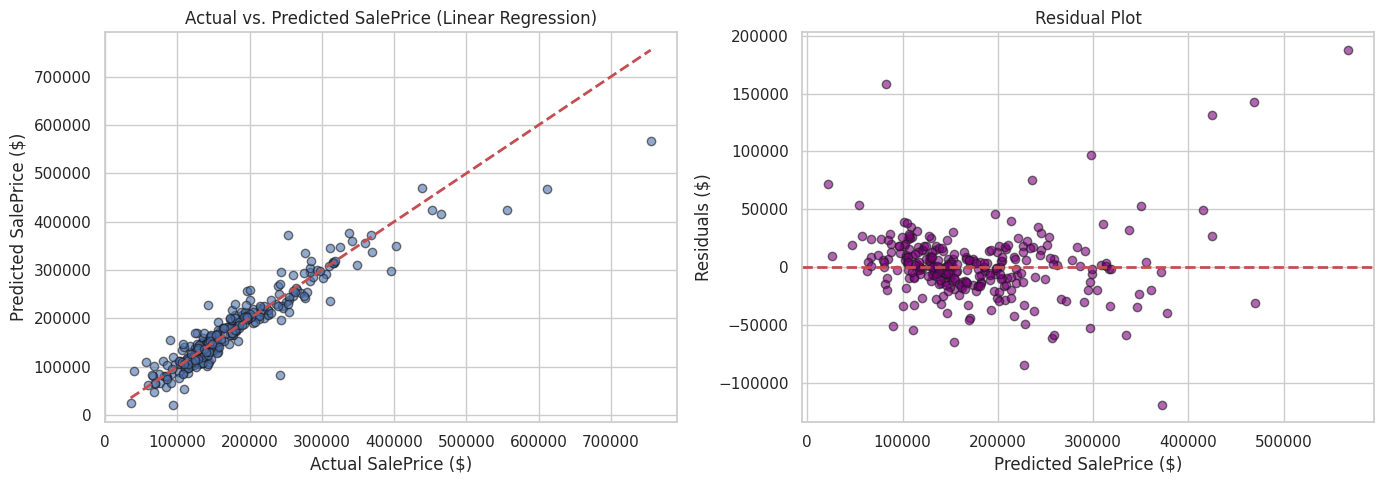


SalePrice skewness (training set): 1.743
Decision: if residuals above show a funnel/heteroscedastic pattern, a log1p target transform is the group's agreed fallback -- to be confirmed jointly with Role B's skewness analysis in Notebook 2 before changing the shared target.


In [11]:
# Diagnostic Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color="b", edgecolors="k")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_title("Actual vs. Predicted SalePrice (Linear Regression)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.6, color="purple", edgecolors="k")
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted SalePrice ($)")
axes[1].set_ylabel("Residuals ($)")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_diagnostic_plots.png", dpi=150)
plt.show()

target_skew = y_train.skew()
print(f"\nSalePrice skewness (training set): {target_skew:.3f}")
print("Decision: if residuals above show a funnel/heteroscedastic pattern, a log1p target "
      "transform is the group's agreed fallback -- to be confirmed jointly with Role B's "
      "skewness analysis in Notebook 2 before changing the shared target.")

## Decision Log

| # | Decision | Choice | Reasoning |
|---|---|---|---|
| 1 | Train/test split ratio & seed | 80/20, `random_state=42`, created once here | Matches the group's shared modelling rule; a single fixed split lets every section's results be compared fairly |
| 2 | Baseline metric | Median, not mean | `SalePrice` is right-skewed; mean would be pulled upward by expensive outliers, giving an unrealistically hard floor |
| 3 | Provisional imputation | Median (numeric) / most-frequent (categorical) | Minimal, standard approach appropriate for an initial provisional signal, not the final leakage-safe pipeline |
| 4 | Provisional vs. final sequencing | This notebook's Linear Regression is explicitly provisional | Preserves correct evidence order: baseline first, full pipeline (Notebook 03) after EDA (Notebook 02) |
| 5 | Feature scaling | `StandardScaler` on numeric features only, inside the pipeline | Linear Regression coefficients are scale-sensitive; keeping the scaler inside the `Pipeline` avoids any leakage into the test set |

---

### Downstream Handoff
Subsequent notebooks must load `results/train_indices.csv` and `results/test_indices.csv` (or `results/split_indices.joblib`) to reproduce this exact split - do not re-split the raw dataset.